# Speech Emotion Classification (RAVDESS) with Transformers

## Introduction

This is a **Speech Emotion Classification** project using the **RAVDESS** dataset.

You already downloaded and unzipped the data.

Goal: fine-tune **two Transformer speech models** for emotion classification:

- `facebook/wav2vec2-base`
- `facebook/hubert-base-ls960`

We will follow a realistic evaluation strategy:

- **Speaker-independent split** (no actor leakage)
- Train: `Actor_01` → `Actor_20`
- Val: `Actor_21` → `Actor_22`
- Test: `Actor_23` → `Actor_24`

At the end, we will report:

- Accuracy
- Macro F1
- Confusion matrix
- Classification report


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import numpy as np
import numba
print(np.__version__)
print(numba.__version__)


2.0.2
0.60.0


In [ ]:

from google.colab import drive
drive.mount("/content/drive")



Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive/Speech_classification


Actor_01  Actor_06  Actor_11  Actor_16	Actor_21
Actor_02  Actor_07  Actor_12  Actor_17	Actor_22
Actor_03  Actor_08  Actor_13  Actor_18	Actor_23
Actor_04  Actor_09  Actor_14  Actor_19	Actor_24
Actor_05  Actor_10  Actor_15  Actor_20	Audio_Speech_Actors_01-24.zip


In [ ]:
#  Unzip RAVDESS.


# !unzip /content/drive/MyDrive/Speech_classification/Audio_Speech_Actors_01-24.zip\
#      -d /content/drive/MyDrive/Speech_classification/

In [ ]:
# Install (Colab). If you are local and already installed packages, you can skip.
#!pip -q install -U transformers datasets accelerate evaluate soundfile librosa scikit-learn matplotlib seaborn

# Restart runtime after install if Colab asks you.
print("Ready")


Ready


In [ ]:
#!pip uninstall -y torch torchvision torchaudio
#!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

## 2) Import the missing libraries

In [ ]:
import os
import random
from pathlib import Path

import torch

from datasets import Dataset, DatasetDict, Audio

from transformers import (
    AutoFeatureExtractor,
    AutoModelForAudioClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score


## 3) Reproducibility (seed)

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("CUDA:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")


CUDA: True
Device: NVIDIA A100-SXM4-40GB


## 4) Set your RAVDESS folder (use your already unzipped data)

We will auto-detect the folder.

Expected structure:

- `DATA_DIR/Actor_01/*.wav`
- `DATA_DIR/Actor_02/*.wav`
- ...
- `DATA_DIR/Actor_24/*.wav`


In [ ]:
# Try a few common locations.

# candidate_dirs = []

# candidate_dirs.append(Path("/content/drive/MyDrive/Speech_classification"))
# candidate_dirs.append(Path("/content/drive/MyDrive"))
# candidate_dirs.append(Path("/content"))

# candidate_dirs.append(Path.cwd())
# candidate_dirs.append(Path.cwd() / "Speech_classification")

# candidate_dirs.append(Path.home() / "Downloads")
# candidate_dirs.append(Path.home() / "Downloads" / "Speech_classification")

# DATA_DIR = None

# for d in candidate_dirs:
#     if d.exists() is False:
#         continue

#     if (d / "Actor_01").exists():
#         DATA_DIR = d
#         break

#     for sub in d.iterdir():
#         if sub.is_dir() is False:
#             continue

#         if (sub / "Actor_01").exists():
#             DATA_DIR = sub
#             break

#     if DATA_DIR is not None:
#         break

# print("Detected DATA_DIR:", DATA_DIR)

# if DATA_DIR is None:
#     raise FileNotFoundError("Could not find an unzipped RAVDESS folder that contains Actor_01. Edit candidate_dirs and re-run.")


## 5) Build the dataset table (VERY IMPORTANT)

We build a DataFrame with:

- `path` (audio file path)
- `label` (emotion name)

We will:

- parse emotion from filename
- map emotion code → emotion label name


In [ ]:
# RAVDESS emotion mapping (speech)

emotion_code_to_label = {}

emotion_code_to_label[1] = "neutral"
emotion_code_to_label[2] = "calm"
emotion_code_to_label[3] = "happy"
emotion_code_to_label[4] = "sad"
emotion_code_to_label[5] = "angry"
emotion_code_to_label[6] = "fearful"
emotion_code_to_label[7] = "disgust"
emotion_code_to_label[8] = "surprised"

emotion_code_to_label

{1: 'neutral',
 2: 'calm',
 3: 'happy',
 4: 'sad',
 5: 'angry',
 6: 'fearful',
 7: 'disgust',
 8: 'surprised'}

In [ ]:
from pathlib import Path

DATA_DIR = Path("/content/drive/MyDrive/Speech_classification")

print(DATA_DIR)


/content/drive/MyDrive/Speech_classification


In [ ]:
# Collect all .wav files

wav_paths = []
actors = []

actor_dirs = []
actor_dirs = sorted(list(DATA_DIR.glob("Actor_*")))

print("Number of actor folders:", len(actor_dirs))

for actor_dir in actor_dirs:
    if actor_dir.is_dir() is False:
        continue

    files = []
    files = sorted(list(actor_dir.glob("*.wav")))

    for f in files:
        wav_paths.append(str(f))
        actors.append(actor_dir.name)

print("Number of wav files:", len(wav_paths))
print("Example file:", wav_paths[0] if len(wav_paths) > 0 else None)


Number of actor folders: 24
Number of wav files: 1440
Example file: /content/drive/MyDrive/Speech_classification/Actor_01/03-01-01-01-01-01-01.wav


In [ ]:

# Parse emotion code from filename
# Example filename: 03-01-05-01-01-01-01.wav
# The 3rd group (index 2) is the emotion code.

def parse_emotion_code_from_path(p):
    name = Path(p).stem
    parts = []
    parts = name.split("-")

    code_str = parts[2]

    code_int = int(code_str)

    return code_int

# Quick check
parse_emotion_code_from_path(wav_paths[0])

1

In [ ]:
# Build the DataFrame: path + label

emotion_codes = []

for p in wav_paths:
    code = parse_emotion_code_from_path(p)
    emotion_codes.append(code)

labels = []

for code in emotion_codes:
    label = emotion_code_to_label[code]
    labels.append(label)

df = pd.DataFrame()

df["path"] = wav_paths

df["label"] = labels

# Extra columns (useful, not required)

df["actor"] = actors

df["emotion_code"] = emotion_codes

df.head()

,path,label,actor,emotion_code
0,/content/drive/MyDrive/Speech_classification/A...,neutral,Actor_01,1
1,/content/drive/MyDrive/Speech_classification/A...,neutral,Actor_01,1
2,/content/drive/MyDrive/Speech_classification/A...,neutral,Actor_01,1
3,/content/drive/MyDrive/Speech_classification/A...,neutral,Actor_01,1
4,/content/drive/MyDrive/Speech_classification/A...,calm,Actor_01,2


In [ ]:
# Basic checks

print("Rows:", len(df))
print("Columns:", list(df.columns))

print()
print(df["label"].value_counts())


Rows: 1440
Columns: ['path', 'label', 'actor', 'emotion_code']

label
calm         192
happy        192
sad          192
angry        192
disgust      192
fearful      192
surprised    192
neutral       96
Name: count, dtype: int64


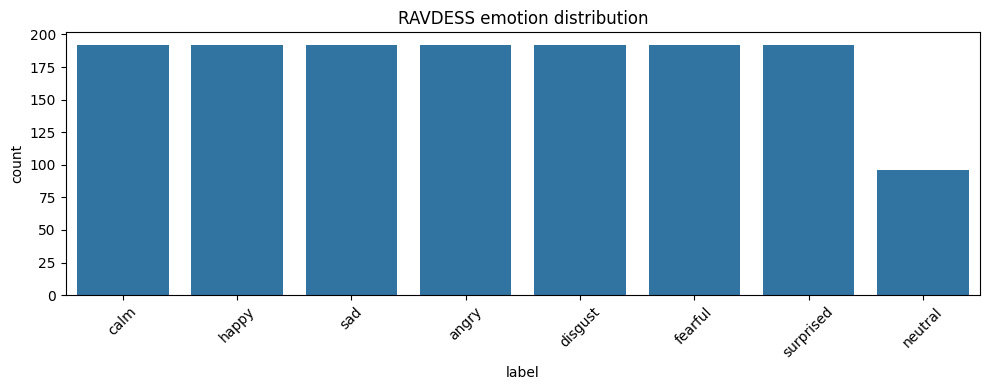

In [ ]:
# Plot label distribution

plt.figure(figsize=(10, 4))

order = []
order = df["label"].value_counts().index.tolist()

sns.countplot(data=df, x="label", order=order)

plt.xticks(rotation=45)
plt.title("RAVDESS emotion distribution")
plt.tight_layout()
plt.show()


## 6) Split the data (speaker-independent)

We will split by actor (speaker):

- Train: `Actor_01` → `Actor_20`
- Val: `Actor_21` → `Actor_22`
- Test: `Actor_23` → `Actor_24`


In [ ]:
# Convert actor folder to actor_id number

def actor_to_id(actor_name):
    actor_id_str = actor_name.replace("Actor_", "")
    actor_id_int = int(actor_id_str)
    return actor_id_int

df["actor_id"] = df["actor"].apply(actor_to_id)

df[["actor", "actor_id"]].drop_duplicates().sort_values("actor_id").head()

,actor,actor_id
0,Actor_01,1
60,Actor_02,2
120,Actor_03,3
180,Actor_04,4
240,Actor_05,5


In [ ]:
# Speaker-independent splits

train_df = df[df["actor_id"] <= 20].copy()
val_df = df[(df["actor_id"] >= 21) & (df["actor_id"] <= 22)].copy()
test_df = df[df["actor_id"] >= 23].copy()

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train rows:", len(train_df))
print("Val rows:", len(val_df))
print("Test rows:", len(test_df))


Train rows: 1200
Val rows: 120
Test rows: 120


In [ ]:
# Verify there is no actor overlap (no cheating)

train_actors = set(train_df["actor_id"].unique())
val_actors = set(val_df["actor_id"].unique())
test_actors = set(test_df["actor_id"].unique())

print("Train actors:", sorted(train_actors))
print("Val actors:", sorted(val_actors))
print("Test actors:", sorted(test_actors))

print("Train ∩ Val:", len(train_actors.intersection(val_actors)))
print("Train ∩ Test:", len(train_actors.intersection(test_actors)))
print("Val ∩ Test:", len(val_actors.intersection(test_actors)))


Train actors: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]
Val actors: [np.int64(21), np.int64(22)]
Test actors: [np.int64(23), np.int64(24)]
Train ∩ Val: 0
Train ∩ Test: 0
Val ∩ Test: 0


## 7) Prepare labels for Transformers

Transformers training needs an integer `label`.

We will keep:

- `label_text` (string)
- `label` (integer)


In [ ]:
# Create label2id and id2label

label_names = []
label_names = sorted(df["label"].unique().tolist())

label2id = {}

for i, name in enumerate(label_names):
    label2id[name] = i

id2label = {}

for name, i in label2id.items():
    id2label[i] = name

print("Labels:", label_names)
print("label2id:", label2id)


Labels: ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
label2id: {'angry': 0, 'calm': 1, 'disgust': 2, 'fearful': 3, 'happy': 4, 'neutral': 5, 'sad': 6, 'surprised': 7}


In [ ]:
# Create model-ready DataFrames

train_df_model = pd.DataFrame()
val_df_model = pd.DataFrame()
test_df_model = pd.DataFrame()

train_df_model["path"] = train_df["path"]
val_df_model["path"] = val_df["path"]
test_df_model["path"] = test_df["path"]

train_df_model["label_text"] = train_df["label"]
val_df_model["label_text"] = val_df["label"]
test_df_model["label_text"] = test_df["label"]

train_df_model["label"] = train_df_model["label_text"].map(label2id)
val_df_model["label"] = val_df_model["label_text"].map(label2id)
test_df_model["label"] = test_df_model["label_text"].map(label2id)

train_df_model.head()

,path,label_text,label
0,/content/drive/MyDrive/Speech_classification/A...,neutral,5
1,/content/drive/MyDrive/Speech_classification/A...,neutral,5
2,/content/drive/MyDrive/Speech_classification/A...,neutral,5
3,/content/drive/MyDrive/Speech_classification/A...,neutral,5
4,/content/drive/MyDrive/Speech_classification/A...,calm,1


## 8) Create Hugging Face Datasets

We will load audio **as raw waveform** and resample to **16 kHz**.


In [ ]:
# Create DatasetDict

train_ds = Dataset.from_pandas(train_df_model, preserve_index=False)
val_ds = Dataset.from_pandas(val_df_model, preserve_index=False)
test_ds = Dataset.from_pandas(test_df_model, preserve_index=False)

dataset = DatasetDict()

dataset["train"] = train_ds
dataset["validation"] = val_ds
dataset["test"] = test_ds

dataset

DatasetDict({
    train: Dataset({
        features: ['path', 'label_text', 'label'],
        num_rows: 1200
    })
    validation: Dataset({
        features: ['path', 'label_text', 'label'],
        num_rows: 120
    })
    test: Dataset({
        features: ['path', 'label_text', 'label'],
        num_rows: 120
    })
})

In [ ]:
#!pip uninstall -y torchcodec


In [ ]:
from datasets import Value

# 1) remove the problematic column first
dataset = dataset.remove_columns(["path"])

# 2) now create a clean string column from your dataframe again (or add it from another source)
# If you still have train_df_model/val_df_model/test_df_model, rebuild dataset cleanly:

# Example if you still have your pandas splits:
from datasets import Dataset, DatasetDict

train_ds = Dataset.from_pandas(train_df_model, preserve_index=False)
val_ds   = Dataset.from_pandas(val_df_model, preserve_index=False)
test_ds  = Dataset.from_pandas(test_df_model, preserve_index=False)

dataset = DatasetDict({
    "train": train_ds,
    "validation": val_ds,
    "test": test_ds
})

# Make sure the path column is a pure string
dataset = dataset.cast_column("path", Value("string"))


Casting the dataset:   0%|          | 0/1200 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/120 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/120 [00:00<?, ? examples/s]

In [ ]:
#!pip install -U "numpy<2.1" numba librosa


In [ ]:
import librosa

def load_audio(example):
    audio, sr = librosa.load(example["path"], sr=16000, mono=True)
    example["audio"] = audio
    example["sampling_rate"] = sr
    return example

dataset = dataset.map(load_audio, batched=False)


Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Map:   0%|          | 0/120 [00:00<?, ? examples/s]

Map:   0%|          | 0/120 [00:00<?, ? examples/s]

## 9) Helper: metrics + evaluation plots

We will reuse these for both Transformer models.


In [ ]:
def plot_confusion_matrix(y_true, y_pred, label_names, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)

    plt.tight_layout()
    plt.show()


In [ ]:
def plot_trainer_history(trainer, title):
    history = []
    history = trainer.state.log_history

    steps = []
    train_loss = []

    eval_steps = []
    eval_loss = []
    eval_acc = []
    eval_f1 = []

    for item in history:
        if "loss" in item and "epoch" in item and "eval_loss" not in item:
            steps.append(item.get("step"))
            train_loss.append(item.get("loss"))

        if "eval_loss" in item:
            eval_steps.append(item.get("step"))
            eval_loss.append(item.get("eval_loss"))
            eval_acc.append(item.get("eval_accuracy"))
            eval_f1.append(item.get("eval_f1_macro"))

    plt.figure(figsize=(10, 4))
    plt.plot(steps, train_loss, label="train_loss")

    if len(eval_steps) > 0:
        plt.plot(eval_steps, eval_loss, label="eval_loss")

    plt.title(title)
    plt.xlabel("step")
    plt.ylabel("loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

    if len(eval_steps) > 0:
        plt.figure(figsize=(10, 4))
        plt.plot(eval_steps, eval_acc, label="eval_accuracy")
        plt.plot(eval_steps, eval_f1, label="eval_f1_macro")
        plt.title(title + " (metrics)")
        plt.xlabel("step")
        plt.ylabel("score")
        plt.legend()
        plt.tight_layout()
        plt.show()


## 10) Preprocess audio for the Transformer

We will:

- use 16 kHz audio
- ensure mono
- pad / truncate to a fixed length


In [ ]:
TARGET_SAMPLING_RATE = 16000

MAX_SECONDS = 4

MAX_LENGTH = TARGET_SAMPLING_RATE * MAX_SECONDS

print("TARGET_SAMPLING_RATE:", TARGET_SAMPLING_RATE)
print("MAX_SECONDS:", MAX_SECONDS)
print("MAX_LENGTH:", MAX_LENGTH)


TARGET_SAMPLING_RATE: 16000
MAX_SECONDS: 4
MAX_LENGTH: 64000


## 11) Transformer Model 1: `facebook/wav2vec2-base`

We will fine-tune this model first.


In [ ]:
model_name_1 = "facebook/wav2vec2-base"

run_name_1 = "wav2vec2_base_ravdess"

print("Model 1:", model_name_1)


Model 1: facebook/wav2vec2-base


In [ ]:
feature_extractor_1 = AutoFeatureExtractor.from_pretrained(model_name_1)

print(feature_extractor_1)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

Wav2Vec2FeatureExtractor {
  "do_normalize": true,
  "feature_extractor_type": "Wav2Vec2FeatureExtractor",
  "feature_size": 1,
  "padding_side": "right",
  "padding_value": 0.0,
  "return_attention_mask": false,
  "sampling_rate": 16000
}



In [ ]:
import numpy as np

def preprocess_batch_model_1(batch):
    audios = batch["audio"]   # list of waveforms (list or np.array)
    out_audio = []

    for arr in audios:
        arr = np.asarray(arr, dtype=np.float32)

        # If somehow it's stereo (2D), make it mono
        if arr.ndim == 2:
            arr = arr.mean(axis=0)

        # Pad / truncate to fixed length
        if len(arr) > MAX_LENGTH:
            arr = arr[:MAX_LENGTH]
        else:
            arr = np.pad(arr, (0, MAX_LENGTH - len(arr)))

        out_audio.append(arr)

    # Use your feature_extractor (already loaded)
    inputs = feature_extractor_1(
        out_audio,
        sampling_rate=TARGET_SAMPLING_RATE,
        padding=False,
        return_attention_mask=True
    )

    # labels must exist in batch (your column "label")
    inputs["labels"] = batch["label"]

    return inputs

In [ ]:
cols_to_remove = []
for c in ["path", "label_text", "audio", "sampling_rate"]:
    if c in dataset.column_names:
        cols_to_remove.append(c)

dataset_model_1 = dataset.map(
    preprocess_batch_model_1,
    batched=True,
    batch_size=8,
    remove_columns=cols_to_remove
)

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Map:   0%|          | 0/120 [00:00<?, ? examples/s]

Map:   0%|          | 0/120 [00:00<?, ? examples/s]

In [ ]:
data_collator_1 = DataCollatorWithPadding(
    tokenizer=feature_extractor_1,
    padding=True,
    return_tensors="pt",
)


In [ ]:
#!pip install -U torch torchvision torchaudio


In [ ]:
model_1 = AutoModelForAudioClassification.from_pretrained(
    model_name_1,
    num_labels=len(label_names),
    label2id=label2id,
    id2label=id2label,
)

print(model_1.config)


pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     | 
-----------------------------+------------+-
quantizer.codevectors        | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
quantizer.weight_proj.weight | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
quantizer.weight_proj.bias   | UNEXPECTED | 
projector.weight             | MISSING    | 
classifier.bias              | MISSING    | 
projector.bias               | MISSING    | 
classifier.weight            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Wav2Vec2Config {
  "activation_dropout": 0.0,
  "adapter_attn_dim": null,
  "adapter_kernel_size": 3,
  "adapter_stride": 2,
  "add_adapter": false,
  "apply_spec_augment": true,
  "architectures": [
    "Wav2Vec2ForPreTraining"
  ],
  "attention_dropout": 0.1,
  "bos_token_id": 1,
  "classifier_proj_size": 256,
  "codevector_dim": 256,
  "contrastive_logits_temperature": 0.1,
  "conv_bias": false,
  "conv_dim": [
    512,
    512,
    512,
    512,
    512,
    512,
    512
  ],
  "conv_kernel": [
    10,
    3,
    3,
    3,
    3,
    2,
    2
  ],
  "conv_stride": [
    5,
    2,
    2,
    2,
    2,
    2,
    2
  ],
  "ctc_loss_reduction": "sum",
  "ctc_zero_infinity": false,
  "diversity_loss_weight": 0.1,
  "do_stable_layer_norm": false,
  "dtype": "float32",
  "eos_token_id": 2,
  "feat_extract_activation": "gelu",
  "feat_extract_norm": "group",
  "feat_proj_dropout": 0.1,
  "feat_quantizer_dropout": 0.0,
  "final_dropout": 0.0,
  "freeze_feat_extract_train": true,
  "hidden_

In [ ]:
#!pip install -U transformers accelerate datasets


In [ ]:
import torch
import inspect
from transformers import TrainingArguments

sig = inspect.signature(TrainingArguments.__init__)
params = sig.parameters

def pick(name_new, name_old):
    # some versions renamed arguments (rare), so we choose what exists
    return name_new if name_new in params else name_old

EVAL_ARG = pick("evaluation_strategy", "eval_strategy")  # handles version differences
SAVE_ARG = pick("save_strategy", "save_strategy")        # usually exists

kwargs = dict(
    output_dir=run_name_1,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_strategy="steps",
    logging_steps=20,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=1,
    report_to="none",
    fp16=torch.cuda.is_available(),
)

# Set eval/save strategy ONLY if your version supports it
if EVAL_ARG in params:
    kwargs[EVAL_ARG] = "epoch"
if SAVE_ARG in params:
    kwargs[SAVE_ARG] = "epoch"

training_args_1 = TrainingArguments(**kwargs)
training_args_1


TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval_use_gather_object=Fals

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)

    f1 = f1_score(labels, preds, average="macro")

    return {"accuracy": acc, "f1_macro": f1}

In [ ]:
trainer_1 = Trainer(
    model=model_1,
    args=training_args_1,
    train_dataset=dataset_model_1["train"],
    eval_dataset=dataset_model_1["validation"],
    data_collator=data_collator_1,
    compute_metrics=compute_metrics,
)

trainer_1

In [ ]:
# Train Model 1

train_result_1 = trainer_1.train()

train_result_1

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.811340,1.674487,0.491667,0.363841
2,1.408273,1.247660,0.691667,0.582584
3,1.083069,1.049605,0.766667,0.757695
4,0.901135,0.981067,0.716667,0.693721
5,0.744139,0.921594,0.758333,0.746009


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=750, training_loss=1.2584295654296875, metrics={'train_runtime': 460.7811, 'train_samples_per_second': 13.021, 'train_steps_per_second': 1.628, 'total_flos': 2.17890736128e+17, 'train_loss': 1.2584295654296875, 'epoch': 5.0})

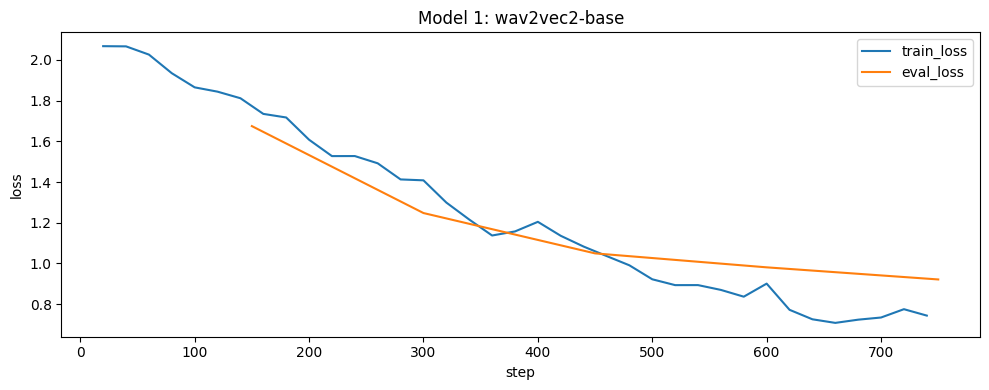

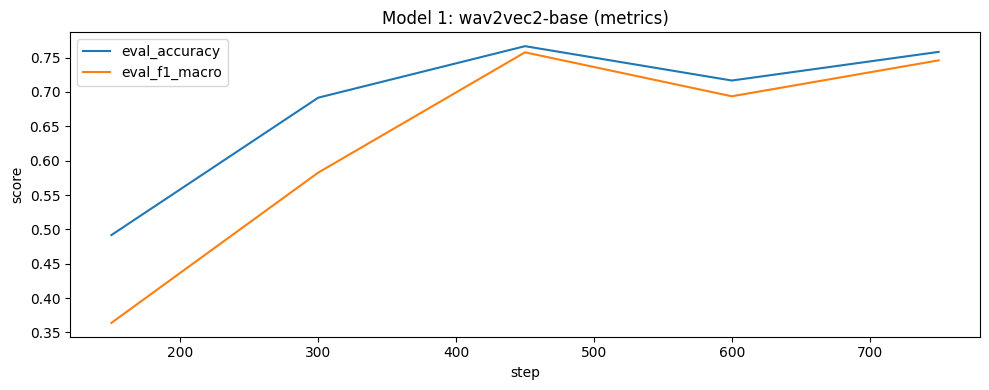

In [ ]:
# Plot training history for Model 1

plot_trainer_history(trainer_1, title="Model 1: wav2vec2-base")

Model 1 test accuracy: 0.65
Model 1 test macro F1: 0.6199244738613553

              precision    recall  f1-score   support

       angry     0.9231    0.7500    0.8276        16
        calm     0.7273    1.0000    0.8421        16
     disgust     0.7895    0.9375    0.8571        16
     fearful     1.0000    0.3750    0.5455        16
       happy     0.3750    0.1875    0.2500        16
     neutral     0.5714    0.5000    0.5333         8
         sad     0.7500    0.3750    0.5000        16
   surprised     0.4324    1.0000    0.6038        16

    accuracy                         0.6500       120
   macro avg     0.6961    0.6406    0.6199       120
weighted avg     0.7044    0.6500    0.6257       120



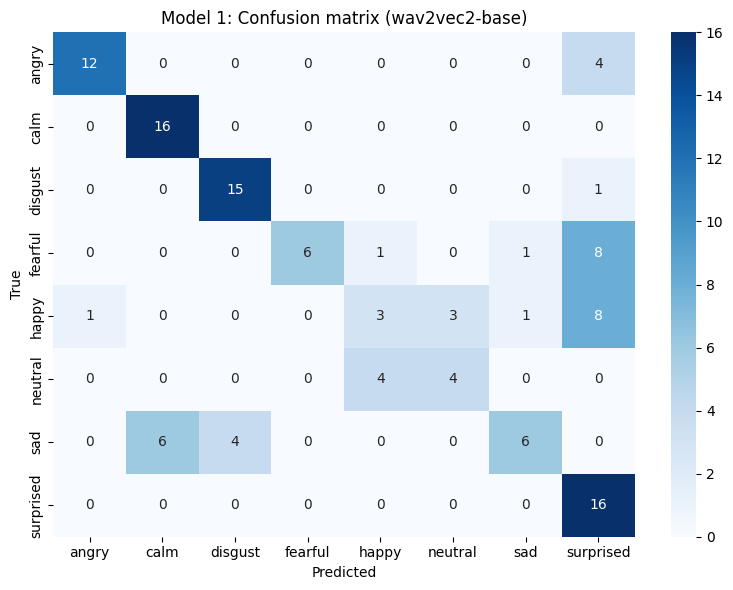

In [ ]:
# Evaluate Model 1 on the test set

pred_1 = trainer_1.predict(dataset_model_1["test"])

y_true_1 = pred_1.label_ids

y_pred_1 = np.argmax(pred_1.predictions, axis=-1)

acc_1 = accuracy_score(y_true_1, y_pred_1)

f1_1 = f1_score(y_true_1, y_pred_1, average="macro")

print("Model 1 test accuracy:", acc_1)
print("Model 1 test macro F1:", f1_1)

print()
print(classification_report(y_true_1, y_pred_1, target_names=label_names, digits=4))

plot_confusion_matrix(y_true_1, y_pred_1, label_names, title="Model 1: Confusion matrix (wav2vec2-base)")

## 12) Transformer Model 2: `facebook/hubert-base-ls960`

Now we train a second Transformer model and compare results.


In [ ]:
# Free memory before starting Model 2 (important on GPU)

import gc

del pred_1

try:
    del trainer_1
except NameError:
    pass

try:
    del model_1
except NameError:
    pass

try:
    del dataset_model_1
except NameError:
    pass

gc.collect()

torch.cuda.empty_cache()

print("Memory cleared")

Memory cleared


In [ ]:
model_name_2 = "facebook/hubert-base-ls960"

run_name_2 = "hubert_base_ravdess"

print("Model 2:", model_name_2)

Model 2: facebook/hubert-base-ls960


In [ ]:
feature_extractor_2 = AutoFeatureExtractor.from_pretrained(model_name_2)

print(feature_extractor_2)

preprocessor_config.json:   0%|          | 0.00/213 [00:00<?, ?B/s]

Wav2Vec2FeatureExtractor {
  "do_normalize": true,
  "feature_extractor_type": "Wav2Vec2FeatureExtractor",
  "feature_size": 1,
  "padding_side": "right",
  "padding_value": 0,
  "return_attention_mask": false,
  "sampling_rate": 16000
}



In [ ]:
import numpy as np

def preprocess_batch_model_2(batch):
    audios_paths = batch["path"]

    # List to hold raw audio NumPy arrays
    raw_audio_arrays = []

    for audio_path in audios_paths:
        # Load audio using librosa
        audio, _ = librosa.load(audio_path, sr=TARGET_SAMPLING_RATE)

        audio = np.asarray(audio, dtype=np.float32)

        # Ensure mono if necessary
        if audio.ndim == 2:
            if audio.shape[0] < audio.shape[1]:
                audio = np.mean(audio, axis=0)
            else:
                audio = np.mean(audio, axis=1)

        # Pad / truncate to fixed length (same idea as Model 1)
        # This avoids: attention_mask has inhomogeneous shapes
        if len(audio) > MAX_LENGTH:
            audio = audio[:MAX_LENGTH]
        else:
            audio = np.pad(audio, (0, MAX_LENGTH - len(audio)))

        raw_audio_arrays.append(audio)

    # Return only the raw audio and the label.
    # The DataCollatorWithPadding will handle feature extraction, padding, and attention_mask.
    return {
        "input_values": raw_audio_arrays,
        "labels": batch["label"], # Note: use 'labels' for the trainer
    }

In [ ]:
# Preprocess dataset for Model 2

cols_to_remove_2 = []
cols_to_remove_2.append("path")
cols_to_remove_2.append("label_text")

dataset_model_2 = dataset.map(
    preprocess_batch_model_2,
    batched=True,
    batch_size=8,
    remove_columns=cols_to_remove_2,
)

dataset_model_2

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Map:   0%|          | 0/120 [00:00<?, ? examples/s]

Map:   0%|          | 0/120 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'audio', 'sampling_rate', 'input_values', 'labels'],
        num_rows: 1200
    })
    validation: Dataset({
        features: ['label', 'audio', 'sampling_rate', 'input_values', 'labels'],
        num_rows: 120
    })
    test: Dataset({
        features: ['label', 'audio', 'sampling_rate', 'input_values', 'labels'],
        num_rows: 120
    })
})

In [ ]:

from transformers import DataCollatorWithPadding

data_collator_2 = DataCollatorWithPadding(
    tokenizer=feature_extractor_2,
    padding=True,
    return_tensors="pt"
)


In [ ]:
model_2 = AutoModelForAudioClassification.from_pretrained(
    model_name_2,
    num_labels=len(label_names),
    label2id=label2id,
    id2label=id2label,
)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

HubertForSequenceClassification LOAD REPORT from: facebook/hubert-base-ls960
Key               | Status  | 
------------------+---------+-
projector.weight  | MISSING | 
classifier.bias   | MISSING | 
projector.bias    | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
import inspect
from transformers import TrainingArguments

sig = inspect.signature(TrainingArguments.__init__)
params = sig.parameters

def pick(name_new, name_old):
    return name_new if name_new in params else name_old

EVAL_ARG = pick("evaluation_strategy", "eval_strategy")
SAVE_ARG = pick("save_strategy", "save_strategy")

kwargs_2 = dict(
    output_dir=run_name_2,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=10,
    weight_decay=0.01,
    logging_strategy="steps",
    logging_steps=20,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=1,
    report_to="none",
    fp16=torch.cuda.is_available(),
)

if EVAL_ARG in params:
    kwargs_2[EVAL_ARG] = "epoch"
if SAVE_ARG in params:
    kwargs_2[SAVE_ARG] = "epoch"

training_args_2 = TrainingArguments(**kwargs_2)
training_args_2

TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval_use_gather_object=Fals

In [ ]:
trainer_2 = Trainer(
    model=model_2,
    args=training_args_2,
    train_dataset=dataset_model_2["train"],
    eval_dataset=dataset_model_2["validation"],
    data_collator=data_collator_2,
    compute_metrics=compute_metrics,
)

trainer_2

In [ ]:
# Train Model 2

train_result_2 = trainer_2.train()

train_result_2

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.112482,1.089972,0.591667,0.544173
2,0.985449,0.875209,0.741667,0.731771
3,0.831334,0.891005,0.733333,0.700637
4,0.811321,1.014898,0.725000,0.681617
5,0.660609,1.151075,0.533333,0.492595
6,0.403704,0.504116,0.825000,0.815620
7,0.423263,0.927880,0.716667,0.680246
8,0.334018,1.017842,0.700000,0.660523
9,0.409004,0.732701,0.750000,0.734200
10,0.338914,0.881823,0.716667,0.691683


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1500, training_loss=0.6436033248901367, metrics={'train_runtime': 494.2043, 'train_samples_per_second': 24.281, 'train_steps_per_second': 3.035, 'total_flos': 4.35781472256e+17, 'train_loss': 0.6436033248901367, 'epoch': 10.0})

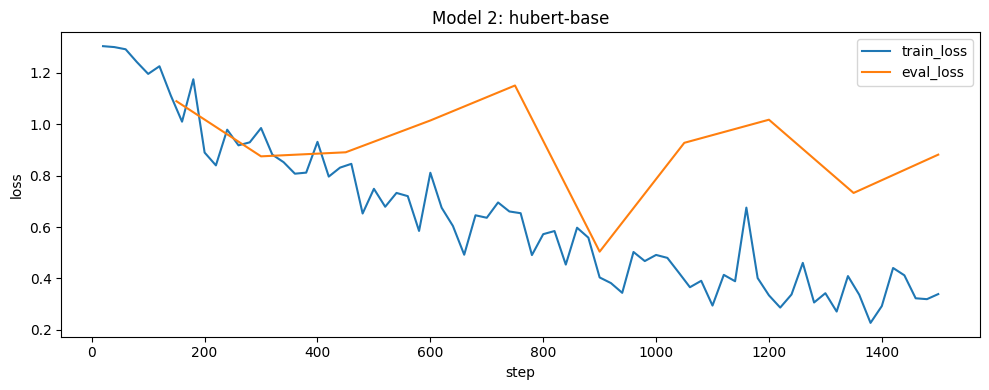

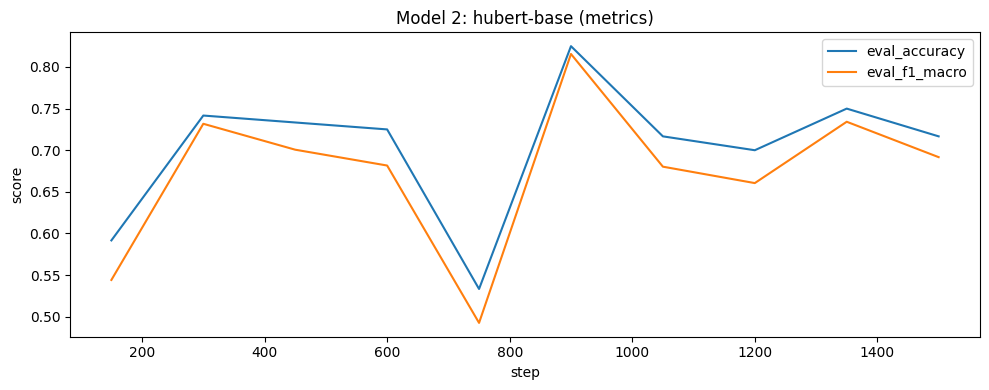

In [ ]:
# Plot training history for Model 2

plot_trainer_history(trainer_2, title="Model 2: hubert-base")


Model 2 test accuracy: 0.675
Model 2 test macro F1: 0.6365927419354839

              precision    recall  f1-score   support

       angry     0.8750    0.8750    0.8750        16
        calm     0.8750    0.8750    0.8750        16
     disgust     1.0000    0.9375    0.9677        16
     fearful     0.8000    0.2500    0.3810        16
       happy     0.5000    0.2500    0.3333        16
     neutral     0.3750    0.3750    0.3750         8
         sad     0.4231    0.6875    0.5238        16
   surprised     0.6154    1.0000    0.7619        16

    accuracy                         0.6750       120
   macro avg     0.6829    0.6562    0.6366       120
weighted avg     0.7035    0.6750    0.6540       120



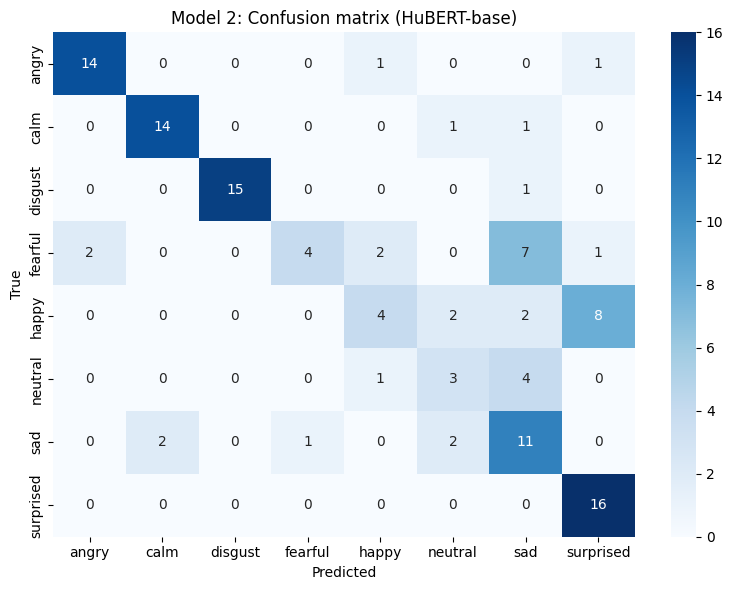

In [ ]:
# Evaluate Model 2 on the test set

pred_2 = trainer_2.predict(dataset_model_2["test"])

y_true_2 = pred_2.label_ids

y_pred_2 = np.argmax(pred_2.predictions, axis=-1)

acc_2 = accuracy_score(y_true_2, y_pred_2)

f1_2 = f1_score(y_true_2, y_pred_2, average="macro")

print("Model 2 test accuracy:", acc_2)
print("Model 2 test macro F1:", f1_2)

print()
print(classification_report(y_true_2, y_pred_2, target_names=label_names, digits=4))

plot_confusion_matrix(y_true_2, y_pred_2, label_names, title="Model 2: Confusion matrix (HuBERT-base)")


## 13) Compare results (Model 1 vs Model 2)

In [ ]:
results = []

results.append({"model": model_name_1, "test_accuracy": acc_1, "test_f1_macro": f1_1})
results.append({"model": model_name_2, "test_accuracy": acc_2, "test_f1_macro": f1_2})

results_df = pd.DataFrame(results)

results_df

,model,test_accuracy,test_f1_macro
0,facebook/wav2vec2-base,0.650,0.619924
1,facebook/hubert-base-ls960,0.675,0.636593


<Figure size 800x400 with 0 Axes>

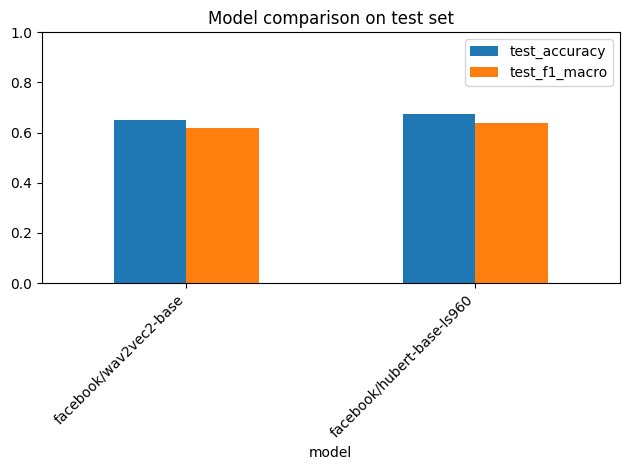

In [ ]:
# Plot comparison

plt.figure(figsize=(8, 4))

results_plot = results_df.copy()

results_plot = results_plot.set_index("model")

results_plot[["test_accuracy", "test_f1_macro"]].plot(kind="bar")

plt.title("Model comparison on test set")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


## Conclusion

We built a complete **speech emotion classification** pipeline on RAVDESS:

- Built the dataset table (`path`, `label`) by parsing filenames
- Used a **speaker-independent split** to avoid actor leakage
- Fine-tuned **two Transformer models**:
  - `facebook/wav2vec2-base`
  - `facebook/hubert-base-ls960`
- Evaluated with:
  - Accuracy
  - Macro F1
  - Confusion matrix
  - Classification report

### Next improvements (optional)

- Try longer `MAX_SECONDS` (e.g. 6–8) if your GPU allows
- Add class weighting (dataset is not perfectly balanced)
- Try data augmentation (noise, pitch) carefully (only on train set)
- Run hyperparameter tuning (learning rate, batch size, epochs)
